<a href="https://colab.research.google.com/github/kumisganteng/Telco-Customer-Churn-Analysis/blob/tahap_eda/Improving_Customer_Retention_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. DATA INGESTION

## 1.1 Pemuatan Data





In [54]:
import pandas as pd

churn_file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
churn_data = pd.read_csv(churn_file_path)



##1.2 Inspeksi Data

In [55]:
churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [56]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [57]:
churn_data.shape

(7043, 21)

## 1.3 Descriptive Statistics

In [58]:
churn_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 2. DATA CLEANING

## 2.1 Mengecek Berapa Banyak Isi Sel Yang Null


In [59]:
churn_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


#### Mengubah sel yg kosong dengan NaN
####Melihat dari hasil pengecekan data kosong, ternyata semua atributnya tidak punya data kosong, maka dari itu kita ubah segala bentuk kekosongan sel menjadi NaN/Null/NA

In [60]:
#Mengeubah kekosongan menjadi NA
churn_data = churn_data.replace(r'^\s*$', pd.NA, regex=True)

In [61]:
churn_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


##2.2 Menghapus Data Kosong
####TotalCharges ternyata ada 11 sel kosong, karena sangat sedikit dari jumlah keseluruhan, maka dihapus saja

In [62]:
#Menghapus data yg kosong
churn_data = churn_data.dropna()

In [63]:
churn_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


###2.3 Menghapus kolom yang tidak kepakai di data analisis
#### customerID tidak memiliki pola(noice),mencegah overfitting, dan bisa mengganggu visualisasi data

In [64]:
#Menghapus customerID
churn_data = churn_data.drop(columns = ['customerID'])

In [65]:
# cek kolom setelah hapus customerID
churn_data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

###2.4 Menghapus Duplikasi Data

In [66]:
#Mengecek apakah ada baris yg redundan
churn_data.duplicated().sum()

np.int64(22)

####Ditemukan 22 duplicated records yang kemudian dihapus untuk menghindari bias pada model.

In [67]:
#Menghapus baris yg redundan
churn_data = churn_data.drop_duplicates()

###2.5 Validasi Tipe Data

####Mengecek apakah terdapat tipe data yang tidak sesuai dengan yang seharusnya, seperti pada contoh TotalCharges harus memiliki tipe data float, maka diubah

In [68]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 
 17  

In [69]:
#Mengubah tipe data pada TotalCharges menjadi float
churn_data['TotalCharges'] = pd.to_numeric(churn_data['TotalCharges'], errors = 'coerce')

In [70]:
#Setelah itu Mengecek total sel yang isinya null
churn_data['TotalCharges'].isnull().sum()

np.int64(0)

###2.6 Standarisasi Nilai Kategorikal

####Mengecek unique tiap kolom kategori
####Jika terdapat isi sel yang berbagai macam seperti 'NO', 'No', 'no',' no', itu berarti terdapat 4 data yang unik, sehingga harus di jadikan 1 bentuk yg seragam sesuai kesepakatan seperti 'No' agar semua yg no memakai 'No'

In [71]:
for col in churn_data.select_dtypes(include = 'object').columns:
  print(col, churn_data[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn ['No' 'Yes']


####Mengubah isi sel seperti 'No internet service' menjadi No, begitupun untuk kolom yang lainnya

In [72]:
cols_fix = [
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]

for col in cols_fix:
    churn_data[col] = churn_data[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

In [73]:
# Mengecek kembali apakah sidah ada perubahan pada isi sel yang tadi sudah di seragamkan kategorisasinya
for col in churn_data.select_dtypes(include = 'object').columns:
  print(col, churn_data[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes']
OnlineBackup ['Yes' 'No']
DeviceProtection ['No' 'Yes']
TechSupport ['No' 'Yes']
StreamingTV ['No' 'Yes']
StreamingMovies ['No' 'Yes']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn ['No' 'Yes']


##2.7 Validasi Range Numerik

####Mengubah agar Churn tidak bertipe data object lagi tapi agar menjadi tipe data yang bisa dioperasikan

In [74]:
#Mengubah isi data pada Churn menjadi 1 (Yes), dan 0(No)
churn_data['Churn']=churn_data['Churn'].map({'Yes' : 1, 'No' : 0})

In [75]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 
 17  

###Mengecek apakah Tenure ada yang kurang dari 0

In [76]:
churn_data[churn_data['tenure'] <= 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [77]:
# Memastikan secara langsung jumlah tenure ada yg lebih kecil dari 0 atau tidak
(churn_data['tenure'] <= 0).sum()

np.int64(0)

####Mengecek apakah MonthlyCharges ada yg lebih kecil dari 0

In [78]:
churn_data[churn_data['MonthlyCharges'] < 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


####Sekarang cek juga untuk TotalCharges

In [79]:
churn_data[churn_data['TotalCharges'] <= 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


###Mengecek Outlier Pakai IQR

####Hitung Q1 dan Q2

In [80]:
Q1 = churn_data['MonthlyCharges'].quantile(0.25)
Q3 = churn_data['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

####Menentukan Batas Outlier

In [81]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#### Mengambil Data Outlier

In [82]:
outliers = churn_data[
    (churn_data['MonthlyCharges'] < lower_bound) |
    (churn_data['MonthlyCharges'] > upper_bound)
]

outliers.shape

(0, 20)

####Mengecek deskripsi MonthlyCharges

In [83]:
churn_data['MonthlyCharges'].describe()

,MonthlyCharges
count,7010.000000
mean,64.888666
std,30.064769
min,18.250000
25%,35.750000
50%,70.400000
75%,89.900000
max,118.750000


#### Kesimpulannya adalah MonthlyCharges Normal

####Mengecek konsistensi logika layanan
####Kalau PhoneService = 'No'
####maka MultipleLines tidak boleh 'Yes'

In [84]:
phone_conflict = churn_data[
    (churn_data['PhoneService'] == 'No') &
    (churn_data['MultipleLines'] == 'Yes')
]

phone_conflict.shape

(0, 20)

In [85]:
internet_conflict = churn_data[
    (churn_data['InternetService'] == 'No') &
    (
        (churn_data['OnlineSecurity'] == 'Yes') |
        (churn_data['OnlineBackup'] == 'Yes') |
        (churn_data['DeviceProtection'] == 'Yes') |
        (churn_data['TechSupport'] == 'Yes') |
        (churn_data['StreamingTV'] == 'Yes') |
        (churn_data['StreamingMovies'] == 'Yes')
    )
]

In [86]:
internet_conflict.shape

(0, 20)

#### Logika yang di cek sudah benar dan tidak ada yang salah

#3. EXPLORATORY DATA ANALYSIS

##3.1 Univariate Analysis

####Distribusi Target

In [87]:
churn_data['Churn'].value_counts()

,count
Churn,
0,5153
1,1857


####Visualisasi

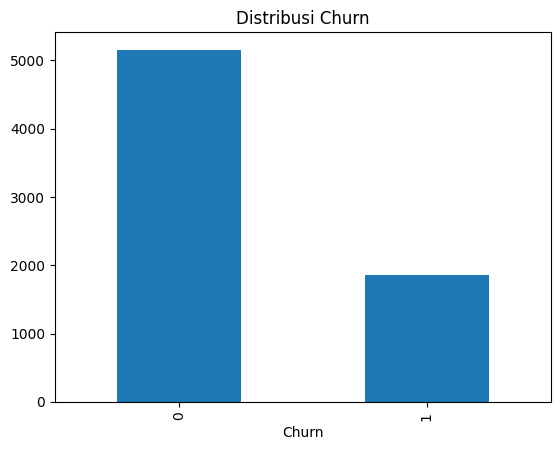

In [88]:
import matplotlib.pyplot as plt

churn_data['Churn'].value_counts().plot(kind='bar')
plt.title('Distribusi Churn')
plt.show()

###Dataset menunjukkan class imbalance dimana pelanggan yang tidak churn jauh lebih dominan dibanding churn. Hal ini perlu diperhatikan pada tahap modeling agar model tidak bias ke kelas mayoritas.


###Distribusi Vitur Numerik = 1.tenure 2. MonthlyCharges 3. Total Charges


#### DVN 'tenure'

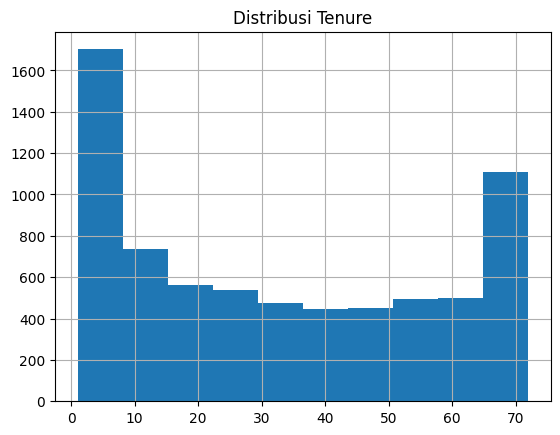

In [89]:
#untuk tenure
churn_data['tenure'].hist()
plt.title('Distribusi Tenure')
plt.show()

####Distribusi tenure menunjukkan pola tidak merata (bimodal/cenderung U-shape), dimana terdapat banyak pelanggan dengan tenure sangat rendah (pelanggan baru) dan juga cukup banyak pelanggan dengan tenure tinggi (pelanggan lama).

####Hal ini mengindikasikan:

####1. Perusahaan terus mendapatkan pelanggan baru (tenure rendah tinggi jumlahnya)

####2. Terdapat kelompok pelanggan loyal dengan masa berlangganan panjang

####3. Periode awal berlangganan kemungkinan merupakan fase kritis yang perlu dianalisis lebih lanjut terhadap churn

####4. Distribusi yang tidak normal ini juga menunjukkan bahwa tenure berpotensi menjadi fitur penting dalam memprediksi churn.

####DVN 'MonthlyCharges'

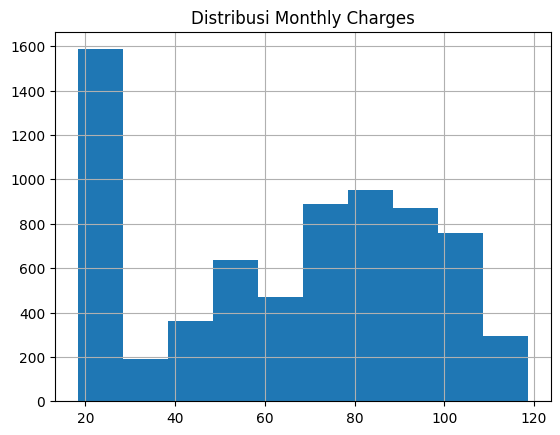

In [90]:
#untuk MonthlyCharges
churn_data['MonthlyCharges'].hist()
plt.title('Distribusi Monthly Charges')
plt.show()

####Distribusi Monthly Charges menunjukkan pola Bimodal (memiliki dua puncak utama), di mana konsentrasi pelanggan terbesar berada pada rentang harga rendah (sekitar 20) dan puncak kedua berada pada rentang harga tinggi (sekitar 70–100).

####Hal ini mengindikasikan:

####1. Segmentasi Pelanggan yang Jelas: Terdapat kelompok pelanggan "Basic" yang kemungkinan besar hanya mengambil layanan minimal (telepon saja) dan kelompok "Premium" yang mengambil paket lengkap (Fiber optic/TV).

####2. Kesenjangan Harga: Sedikitnya jumlah pelanggan pada rentang harga menengah (40–60) menunjukkan bahwa penawaran paket perusahaan cenderung terpolarisasi ke harga murah atau harga mahal.

####3. Risiko Churn pada Segmen Premium: Konsentrasi pelanggan yang cukup besar di angka 70–100 menjadi area krusial, karena biaya yang tinggi seringkali menjadi pemicu utama pelanggan untuk mencari kompetitor.

####4. Target Strategi Retensi: Perusahaan perlu menganalisis lebih dalam apakah tingginya biaya bulanan pada puncak kedua sebanding dengan kepuasan layanan guna mencegah kehilangan pelanggan bernilai tinggi (high-value customers).

####DVN 'TotalCharges'

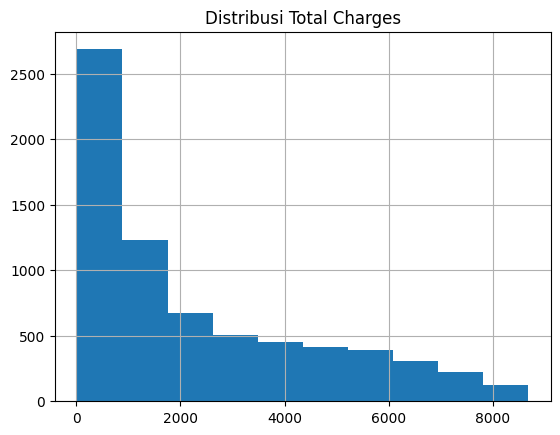

In [91]:
#untuk TotalCharges
churn_data['TotalCharges'].hist()
plt.title('Distribusi Total Charges')
plt.show()

####Distribusi Total Charges menunjukkan pola Positive Skew (miring ke kanan), di mana frekuensi pelanggan menurun seiring bertambahnya jumlah total biaya yang dibayarkan.

####Hal ini mengindikasikan:

####1. Banyaknya Pelanggan Baru: Tingginya jumlah pelanggan di rentang 0-2000 menunjukkan bahwa basis data didominasi oleh pelanggan dengan masa langganan yang masih singkat (low tenure).

####2. Adanya Attrition (Pengurangan): Penurunan drastis pada grafik seiring meningkatnya biaya total mengindikasikan banyak pelanggan yang berhenti berlangganan sebelum mencapai total pembayaran yang tinggi.

####3. Kelompok Pelanggan Loyal: Sebagian kecil pelanggan yang mencapai angka 6000-8000 adalah aset berharga (pelanggan setia jangka panjang) yang perlu dipertahankan.

####4. Kaitan dengan Tenure: Distribusi ini sangat berkorelasi dengan lama berlangganan; semakin lama pelanggan bertahan, semakin besar kontribusi pendapatan (Total Charges) mereka bagi perusahaan.

###Distribusi Fitur Kategorikal

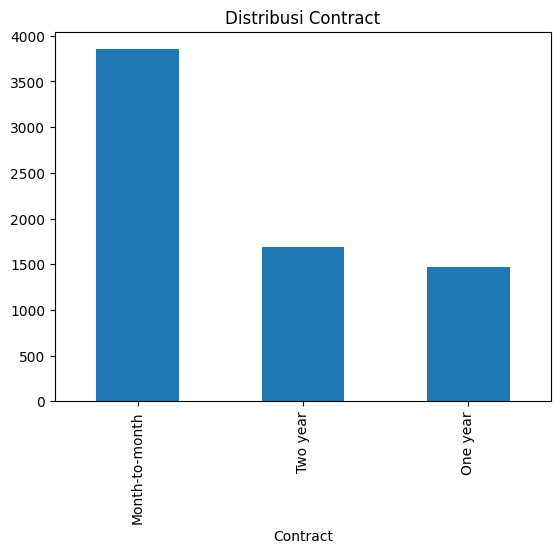

In [92]:
churn_data['Contract'].value_counts().plot(kind='bar')
plt.title('Distribusi Contract')
plt.show()

####Dari visualisasi ini, ada beberapa hal yang bisa disimpulkan:

####1. Risiko Churn (Berhenti Berlangganan): Kontrak Month-to-month memiliki jumlah yang sangat tinggi. Dalam analisis data, tipe kontrak ini biasanya memiliki risiko churn yang lebih besar karena pelanggan bisa berhenti kapan saja tanpa denda besar.

####2. Loyalitas: Pelanggan dengan kontrak Two year cukup signifikan, yang menunjukkan adanya segmen pelanggan loyal yang bersedia mengunci layanan dalam waktu lama.

####3. Strategi Pemasaran: Perusahaan mungkin perlu memberikan insentif lebih (seperti diskon atau fitur tambahan) untuk mendorong pelanggan Month-to-month beralih ke kontrak satu atau dua tahun agar retensi pelanggan lebih stabil.

##3.2 Bivariate Analysis

###Menganalisis Hubungan Churn dengan Fitur Kategorikal

---



####Contract vs Churn



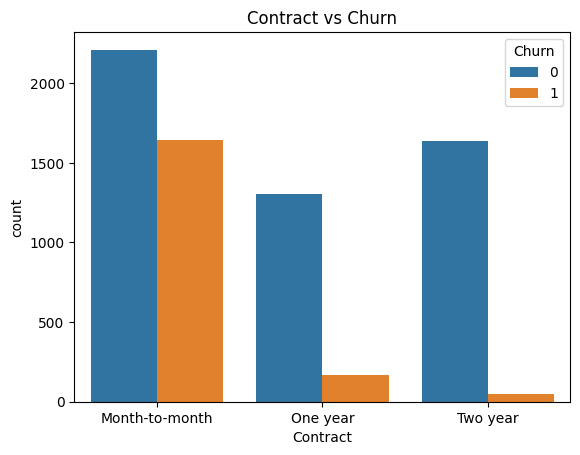

In [93]:
###Hubungan Contract dengan Churn
import seaborn as sns

sns.countplot(x='Contract', hue='Churn', data=churn_data)
plt.title('Contract vs Churn')
plt.show()

####1. Pola Churn Berdasarkan Kontrak
####- Month-to-month (Kontrak Bulanan): Memiliki jumlah pelanggan yang paling banyak berhenti (Churn = 1) dibandingkan jenis kontrak lainnya. Batang oranye di kategori ini sangat tinggi (lebih dari 1.500 pelanggan).

####- One year (Kontrak 1 Tahun): Tingkat churn menurun drastis. Hanya sebagian kecil pelanggan yang berhenti dibandingkan mereka yang tetap bertahan.

####- Two year (Kontrak 2 Tahun): Memiliki tingkat churn paling rendah. Hampir seluruh pelanggan dengan kontrak dua tahun tetap setia (Churn = 0), dan yang berhenti sangat sedikit (hampir tidak terlihat di grafik).

####2. Kesimpulan Utama
####da korelasi negatif yang sangat kuat antara durasi kontrak dan kemungkinan churn: Semakin lama durasi kontrak, semakin rendah kemungkinan pelanggan untuk berhenti.

####3. Rekomendasi Bisnis
####- Berdasarkan data ini, strategi yang bisa diambil perusahaan adalah:

####- Insentif Migrasi: Memberikan promo atau diskon khusus bagi pelanggan bulanan agar mereka mau berpindah ke kontrak minimal 1 tahun.

####- Early Warning: Memfokuskan tim Customer Sucess untuk memantau pelanggan bulanan, karena mereka adalah segmen yang paling rentan pindah ke kompetitor.

####- Retention Program: Memberikan apresiasi (seperti poin atau fitur tambahan) kepada pemegang kontrak 2 tahun agar mereka tetap memperpanjang kontraknya saat masa berlakunya habis.

####TechSupport vs Churn

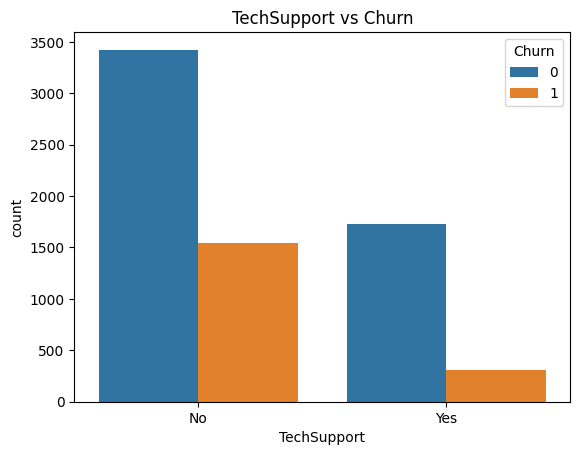

In [94]:
sns.countplot(x='TechSupport', hue='Churn', data=churn_data)
plt.title('TechSupport vs Churn')
plt.show()

####Grafik Contract vs Churn memperjelas temuan dari distribusi sebelumnya:

####1. Risiko Kritikal pada Kontrak Bulanan: Pelanggan dengan kontrak Month-to-month memiliki jumlah churn (batang oranye) yang sangat tinggi, hampir mendekati jumlah pelanggan yang bertahan. Ini menunjukkan bahwa kontrak jangka pendek adalah prediktor kuat bagi pelanggan yang akan berhenti.

####2. Stabilitas Kontrak Jangka Panjang: Pada kontrak One year dan Two year, jumlah pelanggan yang churn jauh lebih sedikit dibandingkan yang bertahan. Kontrak dua tahun menunjukkan tingkat loyalitas tertinggi dengan angka churn yang sangat minimal.

####OnlineSecurity vs Churn

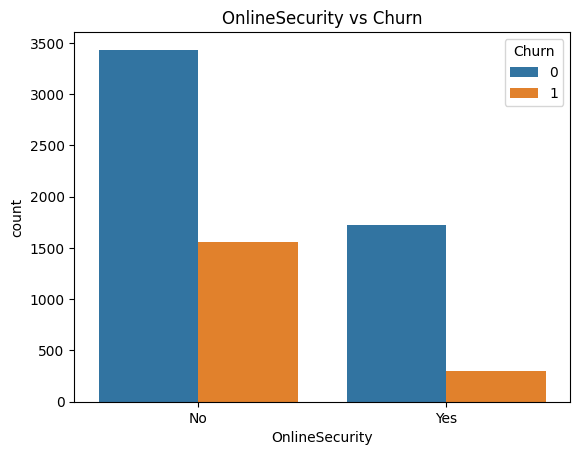

In [95]:
sns.countplot(x='OnlineSecurity', hue='Churn', data=churn_data)
plt.title('OnlineSecurity vs Churn')
plt.show()

####Insight OnlineSecurity vs Churn:
####1. Risiko Tinggi pada Ketidakhadiran Layanan: Pelanggan yang tidak memiliki Online Security (No) menunjukkan jumlah churn (batang oranye) yang sangat masif. Ini mengindikasikan bahwa tanpa perlindungan keamanan digital, pelanggan merasa kurang memiliki "ikatan" atau nilai tambah, sehingga jauh lebih mudah untuk berpindah ke kompetitor.

####2. Keamanan sebagai Jangkar Retensi: Pada pelanggan yang mengaktifkan Online Security (Yes), jumlah churn sangat minimal dibandingkan dengan pelanggan yang bertahan. Hal ini membuktikan bahwa layanan keamanan berfungsi sebagai retention tool yang efektif; pelanggan yang merasa aman dengan layanan tersebut cenderung jauh lebih loyal.

####InternetService vs Churn

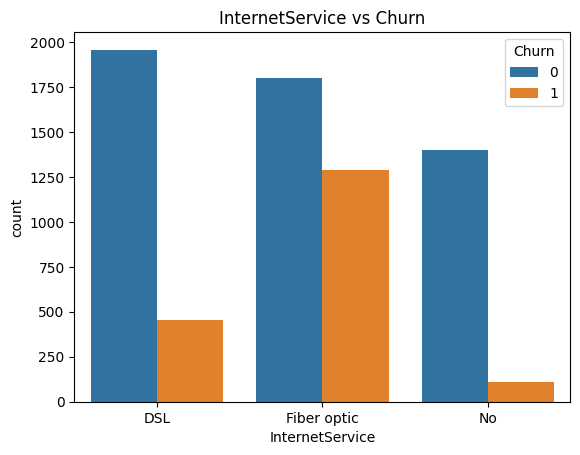

In [96]:
sns.countplot(x='InternetService', hue='Churn', data=churn_data)
plt.title('InternetService vs Churn')
plt.show()

####Insight InternetService vs Churn:
####1. Titik Kritis pada Layanan Fiber Optic: Pelanggan yang menggunakan layanan Fiber optic memiliki proporsi churn (batang oranye) yang sangat mengkhawatirkan. Meskipun teknologi ini menawarkan kecepatan tinggi, jumlah pelanggan yang berhenti hampir mendekati jumlah pelanggan yang bertahan, yang menandakan adanya isu serius pada kepuasan atau harga di segmen ini.

####2.Stabilitas pada Layanan DSL dan Tanpa Internet:

#### -DSL: Pelanggan dengan layanan DSL menunjukkan tingkat loyalitas yang jauh lebih stabil, di mana jumlah yang bertahan (batang biru) mendominasi secara signifikan.

#### -No Internet: Segmen tanpa layanan internet memiliki angka churn paling rendah. Ini menunjukkan bahwa pelanggan paket komunikasi dasar adalah kelompok yang paling kecil kemungkinannya untuk meninggalkan layanan.

####PaymentMethod vs Churn

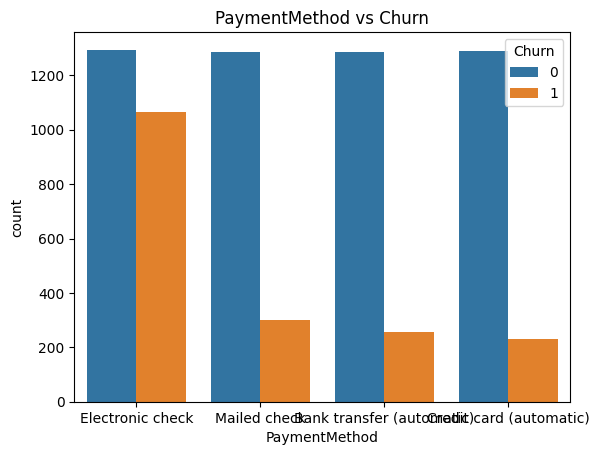

In [97]:
sns.countplot(x='PaymentMethod', hue='Churn', data=churn_data)
plt.title('PaymentMethod vs Churn')
plt.show()

####Insight PaymentMethod vs Churn:
####1. Anomali pada Electronic Check: Metode pembayaran Electronic check menunjukkan risiko churn yang sangat ekstrem, di mana jumlah pelanggan yang berhenti (batang oranye) melebihi 1.000 pelanggan. Angka ini jauh lebih tinggi dibandingkan metode pembayaran lainnya, yang menunjukkan adanya korelasi kuat antara metode pembayaran manual/non-otomatis dengan keputusan untuk berhenti berlangganan.

####2. Efektivitas Sistem Otomatis: Pelanggan yang menggunakan metode pembayaran otomatis, baik melalui Bank transfer (automatic) maupun Credit card (automatic), memiliki tingkat churn yang sangat rendah (di bawah 300 pelanggan). Sistem pembayaran otomatis terbukti menjadi faktor pendukung stabilitas basis pelanggan karena mengurangi hambatan transaksi bulanan.

####tenure vs Churn (boxplot)

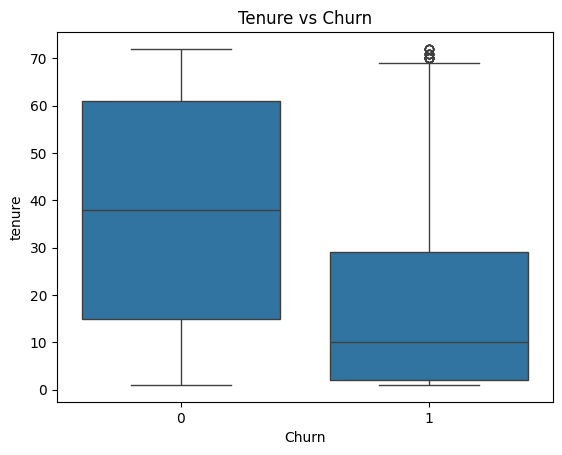

In [98]:
sns.boxplot(x='Churn', y='tenure', data=churn_data)
plt.title('Tenure vs Churn')
plt.show()

####Insight Tenure vs Churn:

####1. Tenure Rendah sebagai Red Flag Utama: Pelanggan yang churn (kelompok 1) memiliki median tenure yang sangat pendek, yakni sekitar 10 bulan, dibandingkan pelanggan yang bertahan dengan median ~38 bulan. Kesenjangan yang sangat jauh ini mengindikasikan bahwa fase awal berlangganan adalah periode paling kritis dan rentan, di mana pelanggan belum memiliki ikatan yang cukup kuat dengan layanan untuk bertahan jangka panjang.
####2. Loyalitas Terbentuk Seiring Waktu: Pelanggan yang tidak churn (kelompok 0) memiliki sebaran tenure yang luas, mulai dari ~2 hingga ~72 bulan, dengan mayoritas berada di kisaran 18–61 bulan. Pola ini menunjukkan bahwa semakin lama seorang pelanggan bertahan, semakin kecil kemungkinan mereka untuk berhenti, sehingga tenure panjang dapat dijadikan indikator loyalitas yang solid dan andal.
####3. Anomali Outlier pada Kelompok Churn: Terdapat sejumlah outlier pada kelompok churn (titik-titik di atas whisker atas) yang merepresentasikan pelanggan dengan tenure tinggi namun tetap memutuskan untuk berhenti berlangganan. Fenomena ini menarik karena bertentangan dengan pola umum — kemungkinan besar dipicu oleh faktor eksternal seperti perubahan harga, penurunan kualitas layanan, atau tawaran kompetitor yang lebih menarik, bukan sekadar faktor kebiasaan berlangganan.

###Churn vs Numerik

####tenure vs Churn (boxplot)

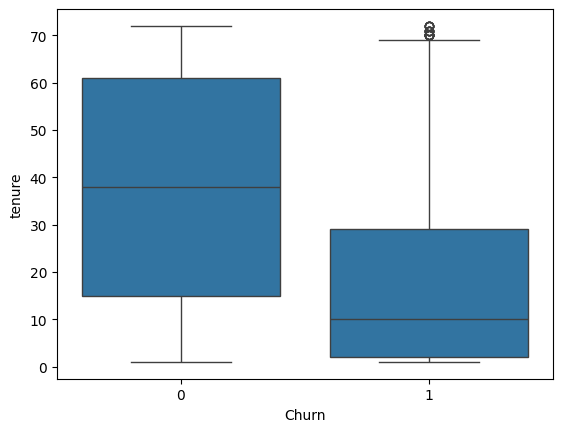

In [99]:
sns.boxplot(x='Churn', y='tenure', data=churn_data)
plt.show()

####Insight Tenure vs Churn:

####1. Kesenjangan Median yang Mencolok sebagai Sinyal Bahaya: Pelanggan yang churn (kelompok 1) memiliki median tenure hanya sekitar 10 bulan, sementara pelanggan yang tidak churn (kelompok 0) berada di angka ~38 bulan. Selisih hampir 4 kali lipat ini secara tegas menunjukkan bahwa pelanggan yang berhenti berlangganan rata-rata adalah mereka yang baru saja bergabung, sehingga tenure rendah dapat dijadikan sinyal peringatan dini yang sangat kuat untuk mendeteksi risiko churn sejak awal.
####2. Stabilitas Pelanggan Jangka Panjang Terbukti Lebih Kuat: Kelompok tidak churn memiliki sebaran data yang jauh lebih luas dengan IQR berkisar antara ~17 hingga ~61 bulan, mencerminkan bahwa pelanggan yang bertahan memiliki profil tenure yang beragam namun konsisten berada di level tinggi. Hal ini mengonfirmasi bahwa semakin lama seorang pelanggan terikat dengan layanan, semakin besar kemungkinan mereka untuk terus bertahan karena sudah terbangun kebiasaan dan ketergantungan terhadap layanan tersebut.
####3. Outlier pada Churn Tinggi: Kegagalan di Luar Faktor Waktu: Sejumlah outlier tampak pada kelompok churn dengan nilai tenure mendekati 70+ bulan, yang berarti ada pelanggan lama yang tetap memutuskan berhenti berlangganan. Fenomena ini mengisyaratkan bahwa tenure panjang saja tidak cukup menjamin retensi — terdapat faktor lain yang turut berperan seperti ketidakpuasan terhadap layanan, perubahan kebutuhan pelanggan, atau penawaran kompetitor yang lebih kompetitif yang perlu diinvestigasi lebih lanjut oleh tim bisnis.

MonthlyCharges vs Churn (boxplot)

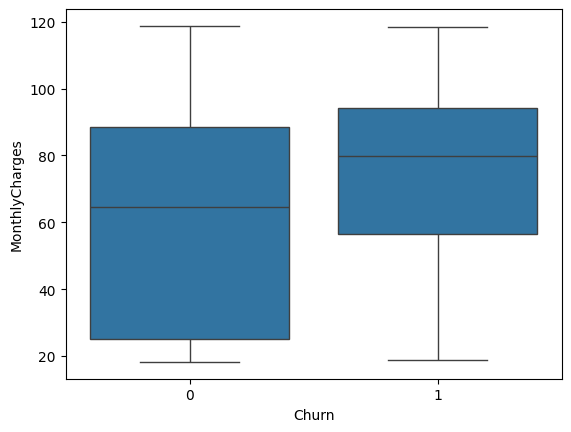

In [100]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=churn_data)
plt.show()

####Insight MonthlyCharges vs Churn:

####1. Tagihan Tinggi sebagai Pemicu Utama Churn: Pelanggan yang churn (kelompok 1) memiliki median MonthlyCharges sekitar ~80, lebih tinggi dibandingkan pelanggan yang tidak churn (kelompok 0) dengan median ~65. Pola ini mengindikasikan adanya korelasi positif antara besarnya tagihan bulanan dengan keputusan berhenti berlangganan — pelanggan yang merasa beban biaya bulanannya terlalu tinggi cenderung lebih mudah tergoda untuk mencari alternatif layanan lain yang lebih terjangkau.
####2. Sebaran Tagihan Pelanggan Churn Lebih Sempit dan Terkonsentrasi di Atas: Kelompok churn memiliki IQR yang berkisar antara ~60 hingga ~95, sementara kelompok tidak churn memiliki IQR yang jauh lebih lebar yakni ~25 hingga ~89. Hal ini menunjukkan bahwa pelanggan yang bertahan memiliki profil tagihan yang sangat beragam — mulai dari paket murah hingga premium — sedangkan pelanggan yang churn didominasi oleh mereka yang berada di segmen tagihan menengah ke atas, yang kemungkinan besar merasa nilai layanan tidak sebanding dengan harga yang dibayarkan.
####3. Segmen Tagihan Rendah Relatif Aman dari Risiko Churn: Whisker bawah kelompok churn dimulai dari angka ~20, namun konsentrasi data mayoritas berada di atas angka 60. Sebaliknya, kelompok tidak churn memiliki banyak pelanggan dengan tagihan rendah yang justru cenderung loyal. Ini mengisyaratkan bahwa strategi penetapan harga yang kompetitif dan paket-paket entry-level yang terjangkau dapat menjadi senjata efektif bagi perusahaan untuk mempertahankan basis pelanggan dan menekan angka churn secara signifikan.

####TotalCharges vs Churn(boxplot)

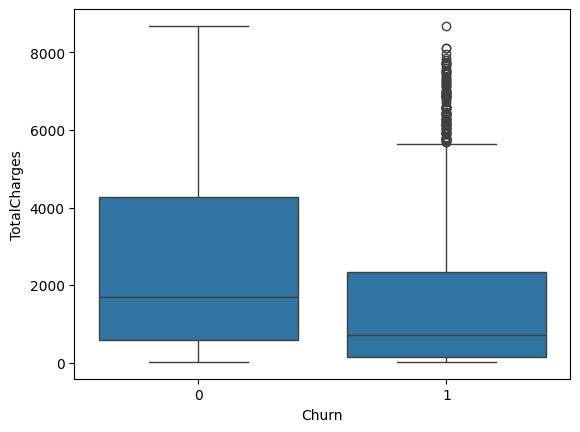

In [101]:
sns.boxplot(x='Churn', y='TotalCharges', data=churn_data)
plt.show()

####Insight TotalCharges vs Churn:

####1. Pelanggan Churn Belum Sempat Berkontribusi Besar Secara Finansial: Pelanggan yang churn (kelompok 1) memiliki median TotalCharges yang sangat rendah, yakni sekitar ~700, jauh di bawah kelompok tidak churn (kelompok 0) dengan median ~1.700. Pola ini sangat konsisten dengan temuan pada variabel tenure sebelumnya — pelanggan yang berhenti adalah mereka yang baru sebentar berlangganan sehingga akumulasi total tagihan mereka pun masih minim. Artinya, churn tidak hanya merugikan dari sisi kehilangan pelanggan, tetapi juga dari sisi rendahnya lifetime value yang berhasil diekstrak dari pelanggan tersebut.
####2. Kelompok Tidak Churn Memiliki Sebaran TotalCharges yang Jauh Lebih Luas: IQR kelompok tidak churn membentang dari ~800 hingga ~4.300, mencerminkan basis pelanggan yang beragam mulai dari yang baru bergabung hingga pelanggan lama dengan akumulasi tagihan tinggi. Sebaliknya, IQR kelompok churn yang hanya berkisar ~200 hingga ~2.300 menunjukkan bahwa mayoritas pelanggan yang berhenti adalah mereka yang belum cukup lama bertahan untuk mengakumulasi tagihan yang signifikan, sehingga potensi pendapatan jangka panjang mereka tidak pernah terealisasi.
####3. Outlier Ekstrem pada Kelompok Churn: Kehilangan Pelanggan Premium yang Mengkhawatirkan: Terdapat sejumlah outlier yang sangat mencolok pada kelompok churn dengan nilai TotalCharges mencapai angka 6.000–8.000 ke atas. Fenomena ini sangat kritis karena mengindikasikan bahwa perusahaan tidak hanya kehilangan pelanggan baru, tetapi juga kehilangan pelanggan lama bernilai tinggi yang selama ini menjadi kontributor pendapatan signifikan. Investigasi mendalam terhadap segmen outlier ini perlu diprioritaskan untuk memahami akar penyebab kepergian mereka dan mencegah kejadian serupa di masa mendatang.

###Correlation Numeric

####Melihat apakah ada hubungan kuat antar variabel numerik (multicollinearity & insight pola)

In [102]:
churn_data[['tenure','MonthlyCharges','TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.244194,0.825293
MonthlyCharges,0.244194,1.000000,0.650540
TotalCharges,0.825293,0.650540,1.000000


####Menampilkan visual dari tabel korelasi

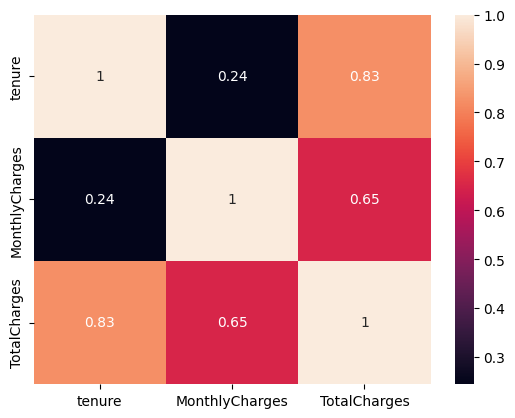

In [103]:
sns.heatmap(
    churn_data[['tenure','MonthlyCharges','TotalCharges']].corr(),
    annot=True
)
plt.show()

###Churn Rate per Kategori

In [104]:
churn_data.groupby('Contract')['Churn'].value_counts(normalize=True)

Contract        Churn
Month-to-month  0        0.573579
                1        0.426421
One year        0        0.887228
                1        0.112772
Two year        0        0.971513
                1        0.028487
Name: proportion, dtype: float64

####Insight Churn Rate per Kategori Contract:

####Month-to-month: Bom Waktu yang Paling Berbahaya: Pelanggan dengan kontrak bulanan mencatatkan churn rate tertinggi sebesar 42,6%, artinya hampir separuh dari seluruh pelanggan di segmen ini memilih untuk berhenti berlangganan. Fleksibilitas kontrak bulanan yang tidak mengikat justru menjadi bumerang bagi perusahaan, karena pelanggan dapat dengan mudah keluar kapan saja tanpa konsekuensi finansial apapun, sehingga loyalitas mereka sangat rendah dan rentan terhadap tawaran kompetitor.
####Kontrak Jangka Panjang Terbukti Menjadi Benteng Retensi Terkuat: Terdapat penurunan churn rate yang sangat drastis seiring dengan lamanya durasi kontrak — dari 42,6% pada kontrak bulanan, turun tajam menjadi 11,3% pada kontrak satu tahun, dan mencapai titik terendah hanya 2,8% pada kontrak dua tahun. Pola penurunan yang sangat konsisten ini secara tegas membuktikan bahwa komitmen kontrak jangka panjang adalah instrumen retensi paling efektif yang dimiliki perusahaan saat ini.
####Gap 15x antara Kontrak Bulanan dan Dua Tahun: Peluang Strategis yang Harus Dimanfaatkan: Selisih churn rate antara kontrak month-to-month (42,6%) dan two year (2,8%) yang mencapai hampir 15 kali lipat merupakan sinyal strategis yang sangat kuat. Perusahaan berpotensi menekan angka churn secara masif apabila mampu mendorong migrasi pelanggan dari kontrak bulanan ke kontrak jangka panjang, misalnya melalui insentif diskon, bonus fitur eksklusif, atau program upgrade kontrak yang menarik dan menguntungkan bagi pelanggan.